In [3]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [4]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod
from datatools.DOT.DataServer import DataServer

In [5]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BG_LSSL_CTD_2003-2025.nc")

#Slice the data to extract each transect
#Eastern N-S transect (IVO 140˚W)
e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)
#ADD OTHER THREE TRANSECTS

In [6]:
#Split data into a dataset per cruise 
e_ns_cruise_transects = dsops.split_by_coordinate(e_ns_transect, 'cruise')
#Clean each dataset
for key in e_ns_cruise_transects:
    #Clean and injest the transect data (add many new and useful variables)
    e_ns_cruise_transects[key] = dsops.injest_CTD_transect(e_ns_cruise_transects[key], datum=(70,-140))

In [7]:
#Load in Satellite Data
sat_data = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

for key in e_ns_cruise_transects:
    transect = e_ns_cruise_transects[key]

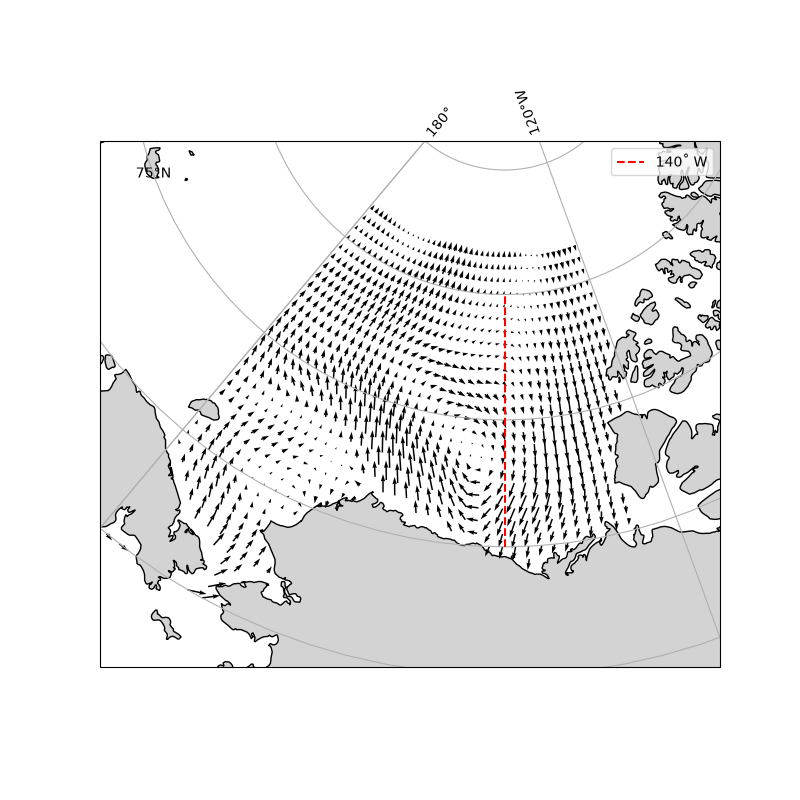

In [42]:
#Setup the basemap
year = 2008
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]
step = 2

sub_ds = sat_data.sat_ds_old.sel(lat = slice(65,85,step), lon = slice(-180,-120,step), time = np.datetime64(f"{year}-09-01"))

lon_mesh, lat_mesh = np.meshgrid(sub_ds['lon'], sub_ds['lat'])

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot the surface currents
ax.quiver(lon_mesh, lat_mesh, sub_ds['U'].values, sub_ds['V'].values, transform = ccrs.PlateCarree())

ax.plot([-140,-140], [70,80], 'r--',transform = ccrs.PlateCarree(), label = '140˚ W')

#Finish the plot off
plt.title(f"{year} Geostrophic Surface Currents") #WHY DOESNT THIS WORK?

plt.legend()
plt.show()



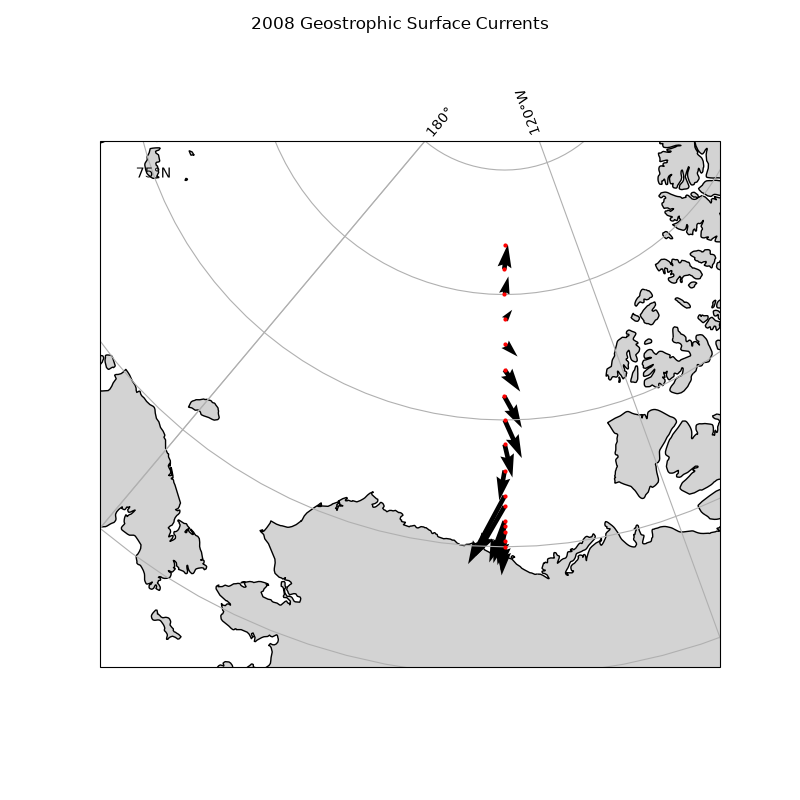

In [40]:
transect = e_ns_cruise_transects[year]
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all stations
ax = mapper.plot_locations(ax, transect['lat'], transect['lon'], color = 'r', label = 'Stations')

#Get the surface currents
_, u_geo_surf_current, v_geo_surf_current = sat_data.get(transect['date'], transect['lat'], transect['lon'], priority='old')

#Plot the surface currents
ax.quiver(transect['lon'], transect['lat'], np.array(u_geo_surf_current), np.array(v_geo_surf_current), transform = ccrs.PlateCarree())


#Finish the plot off
transect_location_figure.suptitle(f"{year} Geostrophic Surface Currents") #WHY DOESNT THIS WORK?

plt.show()

In [22]:
transect['date']

<xarray.DataArray 'date' (station: 8)> Size: 64B
array(['2004-08-28T22:46:18.000000000', '2004-08-29T06:33:09.000000000',
       '2004-08-28T05:46:49.000000000', '2004-08-24T22:36:54.000000000',
       '2004-08-23T17:18:00.000000000', '2004-08-23T06:03:52.000000000',
       '2004-08-20T23:19:09.000000000', '2004-08-21T17:31:16.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * station  (station) int64 64B 46 47 45 38 35 34 32 33
    cruise   int64 8B 2004